In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
credit_card_data = pd.read_csv("creditcard.csv")

In [3]:
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
legit = credit_card_data[credit_card_data.Class ==0]
fraud = credit_card_data[credit_card_data.Class == 1]

In [5]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [6]:
#compare the values for both transcation
credit_card_data.groupby("Class").mean() #stastical analysis


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [7]:
legit_sample = legit.sample(n= 492)

In [8]:
new_dataset =pd.concat([legit_sample,fraud],axis=0)

In [9]:
new_dataset['Class'].value_counts()


Class
0    492
1    492
Name: count, dtype: int64

splitting the data into features and targets

In [10]:
X = new_dataset.drop(columns ="Class",axis=1)

Y = new_dataset["Class"]

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## splitting data into training data and test data 

In [12]:
X_train,X_test,Y_train,Y_test = train_test_split(
        X,Y,test_size=0.2,stratify = Y,random_state = 2
)

In [13]:
print(X.shape,X_train.shape,X_test.shape)

(984, 30) (787, 30) (197, 30)


## MODEL TRAINING

In [14]:
model = LogisticRegression()

model.fit(X_train,Y_train)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Model Evaluation

In [15]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction,Y_train)

print("Accuracy on Training data:",training_data_accuracy)


X_test_prediction = model.predict(X_test)
testing_data_accuracy = accuracy_score(X_test_prediction,Y_test)

print("Accuracy on Testing data:",training_data_accuracy)

Accuracy on Training data: 0.9440914866581956
Accuracy on Testing data: 0.9440914866581956


DECISION TREE

In [16]:
from sklearn.tree import DecisionTreeClassifier


dtree = DecisionTreeClassifier(criterion = "entropy",random_state = 0)

dtree.fit(X_train,Y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
predictions = dtree.predict(X_test)

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test,predictions))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90        99
           1       0.91      0.89      0.90        98

    accuracy                           0.90       197
   macro avg       0.90      0.90      0.90       197
weighted avg       0.90      0.90      0.90       197



In [19]:
print(confusion_matrix(Y_test,predictions))

[[90  9]
 [11 87]]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10640\2499258902.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


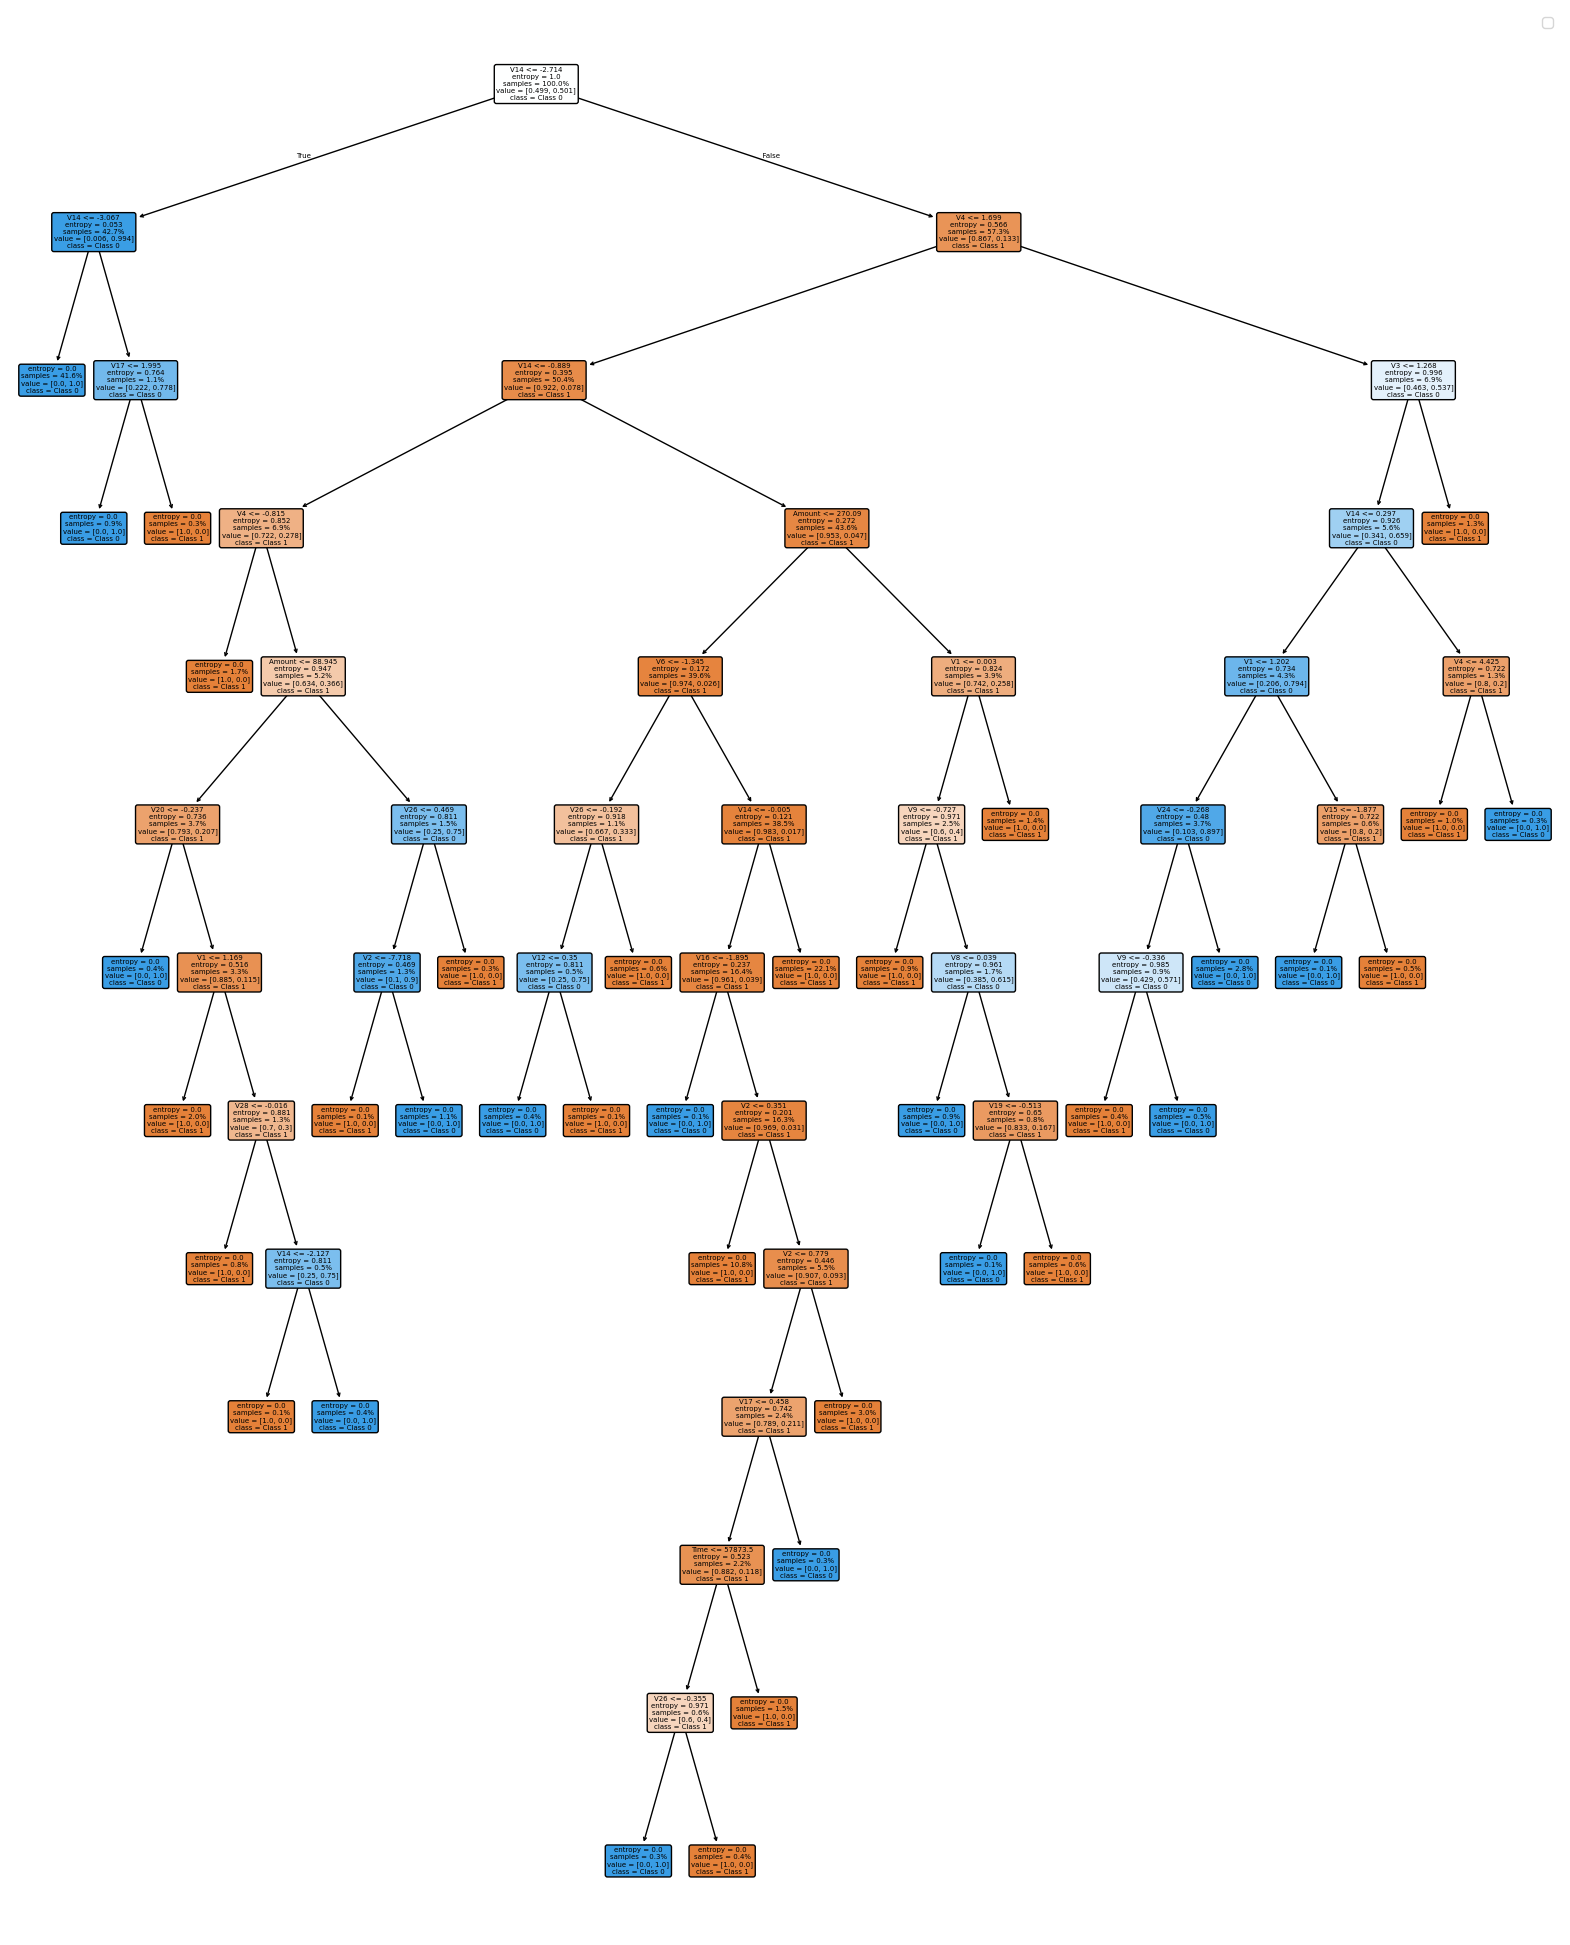

In [20]:
from sklearn import tree

plt.figure(figsize=(20,25))

tree.plot_tree(
    dtree,feature_names = X.columns,
    class_names = ["Class 1","Class 0"],
    rounded=True, #the corners of the box nodes in the diagram
    filled = True,#filled = True: This color-codes the nodes. 
    #Nodes that lean heavily toward one class will be colored deep blue, while nodes leaning toward the other class turn deep orange. 
   
    proportion = True
)
plt.legend()
plt.show()

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train the model
lr_model = LogisticRegression(random_state=2)
lr_model.fit(X_train, Y_train)

# Prediction
lr_predictions = lr_model.predict(X_test)

# Evaluation
print(confusion_matrix(Y_test, lr_predictions))
print(classification_report(Y_test, lr_predictions))

[[95  4]
 [11 87]]
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        99
           1       0.96      0.89      0.92        98

    accuracy                           0.92       197
   macro avg       0.93      0.92      0.92       197
weighted avg       0.93      0.92      0.92       197



C:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KNN

In [22]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

In [23]:
# 1. Properly scale features after dropping 'Class' along the column axis (axis=1)
X = pd.DataFrame(
    scaler.fit_transform(credit_card_data.drop("Class", axis=1))
    
)

# 2. Assign the target variable
Y = credit_card_data['Class']


In [24]:
#using knn 

from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors =1)

In [25]:
knn.fit(X_train,Y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
#prediciton and evaluation

pred = knn.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(Y_test,pred))

print(classification_report(Y_test,pred))

[[72 27]
 [34 64]]
              precision    recall  f1-score   support

           0       0.68      0.73      0.70        99
           1       0.70      0.65      0.68        98

    accuracy                           0.69       197
   macro avg       0.69      0.69      0.69       197
weighted avg       0.69      0.69      0.69       197



In [27]:
from sklearn.model_selection import train_test_split

# Take a random sample of 20,000 rows
X_sample = X.sample(n=20000, random_state=42)
Y_sample = Y.loc[X_sample.index]

X_train, X_test, Y_train, Y_test = train_test_split(
    X_sample, Y_sample, test_size=0.3, random_state=42
)

In [28]:
error_rate = []

for i in range(1, 40):
    print(f"Running k = {i}")

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, Y_train)

    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != Y_test))

Running k = 1
Running k = 2
Running k = 3
Running k = 4
Running k = 5
Running k = 6
Running k = 7
Running k = 8
Running k = 9
Running k = 10
Running k = 11
Running k = 12
Running k = 13
Running k = 14
Running k = 15
Running k = 16
Running k = 17
Running k = 18
Running k = 19
Running k = 20
Running k = 21
Running k = 22
Running k = 23
Running k = 24
Running k = 25
Running k = 26
Running k = 27
Running k = 28
Running k = 29
Running k = 30
Running k = 31
Running k = 32
Running k = 33
Running k = 34
Running k = 35
Running k = 36
Running k = 37
Running k = 38
Running k = 39


Text(0, 0.5, 'Error Rate')

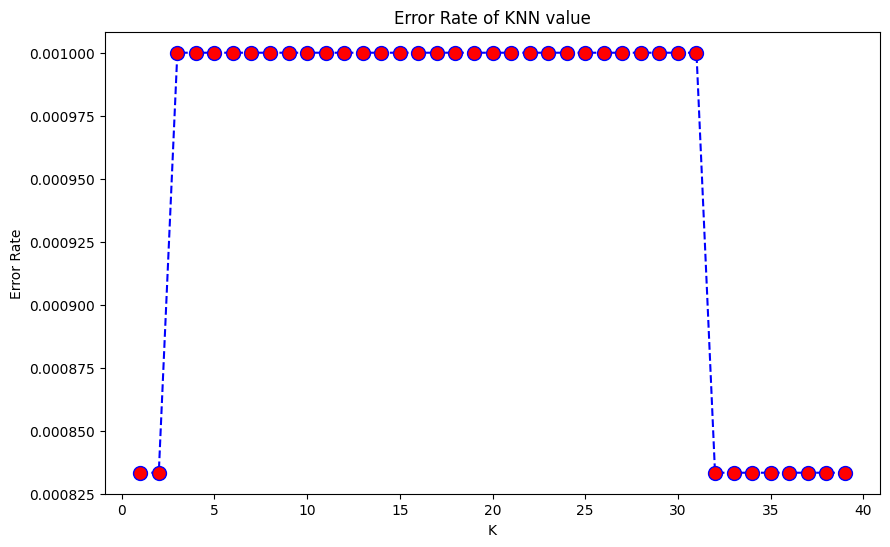

In [29]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,40),
    error_rate,
    color ='Blue', linestyle = "--",marker= 'o',
    markerfacecolor = "red",
    markersize = 10
    
)
plt.title("Error Rate of KNN value")
plt.xlabel("K")
plt.ylabel("Error Rate")

In [30]:
#keeping K=1

knn = KNeighborsClassifier(n_neighbors = 1)

knn.fit(X_train,Y_train)
pred = knn.predict(X_test)

print("With k=1")
print("\n")
print(confusion_matrix(Y_test, pred))
print("\n") 
print(classification_report(Y_test, pred))

With k=1


[[5991    1]
 [   4    4]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5992
           1       0.80      0.50      0.62         8

    accuracy                           1.00      6000
   macro avg       0.90      0.75      0.81      6000
weighted avg       1.00      1.00      1.00      6000



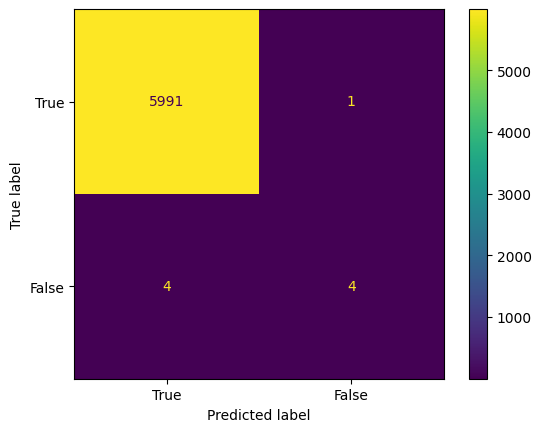

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
pred = knn.predict(X_test)

# Create confusion matrix
conf_matrix = confusion_matrix(Y_test, pred)

# Display confusion matrix
vis = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=[True, False]
)

vis.plot()
plt.grid(False)
plt.show()

MODEL COMPARSION

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,  
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


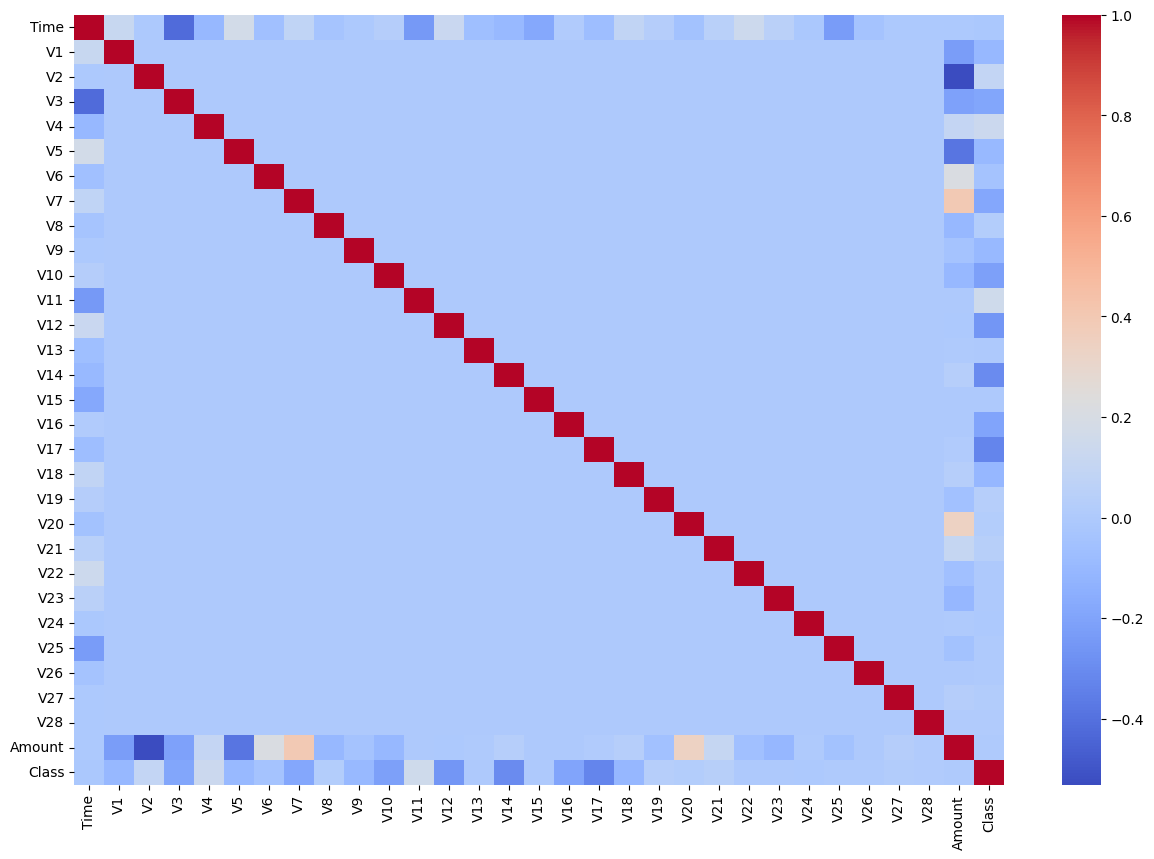

In [33]:
plt.figure(figsize = (15,10))
sns.heatmap(credit_card_data.corr(),cmap = 'coolwarm',annot = False)
plt.show()

In [34]:
X = credit_card_data.drop("Class",axis = 1)

Y = credit_card_data["Class"]

X_train,X_test,Y_train,Y_test = train_test_split(
        X,Y,test_size=0.30)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [35]:
model1 = LogisticRegression()
model2 = KNeighborsClassifier()
model3 = DecisionTreeClassifier()

model1.fit(X_train,Y_train)
model2.fit(X_train,Y_train)
model3.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
Y_pred1 = model1.predict(X_test)
Y_pred2 = model2.predict(X_test)
Y_pred3 = model3.predict(X_test)

In [37]:
acc1 = accuracy_score(Y_test,Y_pred1)
prec1 = precision_score(Y_test,Y_pred1)
rec1 = recall_score(Y_test,Y_pred1)
f1_1 = f1_score(Y_test,Y_pred1)


acc2 = accuracy_score(Y_test,Y_pred2)
prec2 = precision_score(Y_test,Y_pred2)
rec2 = recall_score(Y_test,Y_pred2)
f1_2 = f1_score(Y_test,Y_pred2)


acc3 = accuracy_score(Y_test,Y_pred3)
prec3 = precision_score(Y_test,Y_pred3)
rec3 = recall_score(Y_test,Y_pred3)
f1_3 = f1_score(Y_test,Y_pred3)

In [38]:
results = pd.DataFrame(
    {
        "Model":["Logistic Regression","KNN","Decision Tree"],
        "Accuracy":[acc1,acc2,acc3],
        "Percision": [prec1,prec2,prec3],
        "Recall":[rec1,rec2,rec3],
        "F1_score":[f1_1,f1_2,f1_3]
    }
)

In [39]:
print("Model Comparision:")

print(results.sort_values(by="Accuracy", ascending=False))


Model Comparision:
                 Model  Accuracy  Percision    Recall  F1_score
1                  KNN  0.999520   0.954128  0.742857  0.835341
2        Decision Tree  0.999134   0.770492  0.671429  0.717557
0  Logistic Regression  0.999111   0.840426  0.564286  0.675214


In [40]:
timedelta = pd.to_timedelta(credit_card_data['Time'],unit = 's')
credit_card_data['Time_min'] = (timedelta.dt.components.minutes).astype(int)
credit_card_data['Time_hour'] = (timedelta.dt.components.minutes).astype(int)

In [41]:
import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10640\605342932.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(credit_card_data[credit_card_data['Class']==0]["Time_hour"],color= 'g')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10640\605342932.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

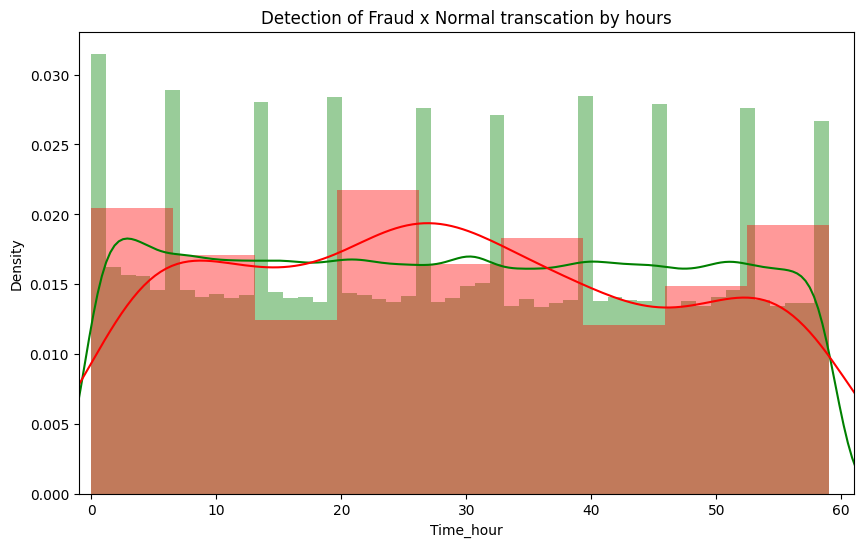

In [42]:
plt.figure(figsize=(10,6))
sns.distplot(credit_card_data[credit_card_data['Class']==0]["Time_hour"],color= 'g')
sns.distplot(credit_card_data[credit_card_data['Class']==1]["Time_hour"],color= 'r')

plt.title("Detection of Fraud x Normal transcation by hours", fontsize=12 )
plt.xlim([-1,61])
plt.show()

In [43]:
credit_card_data['Amount_log'] = np.log(credit_card_data.Amount+0.01)

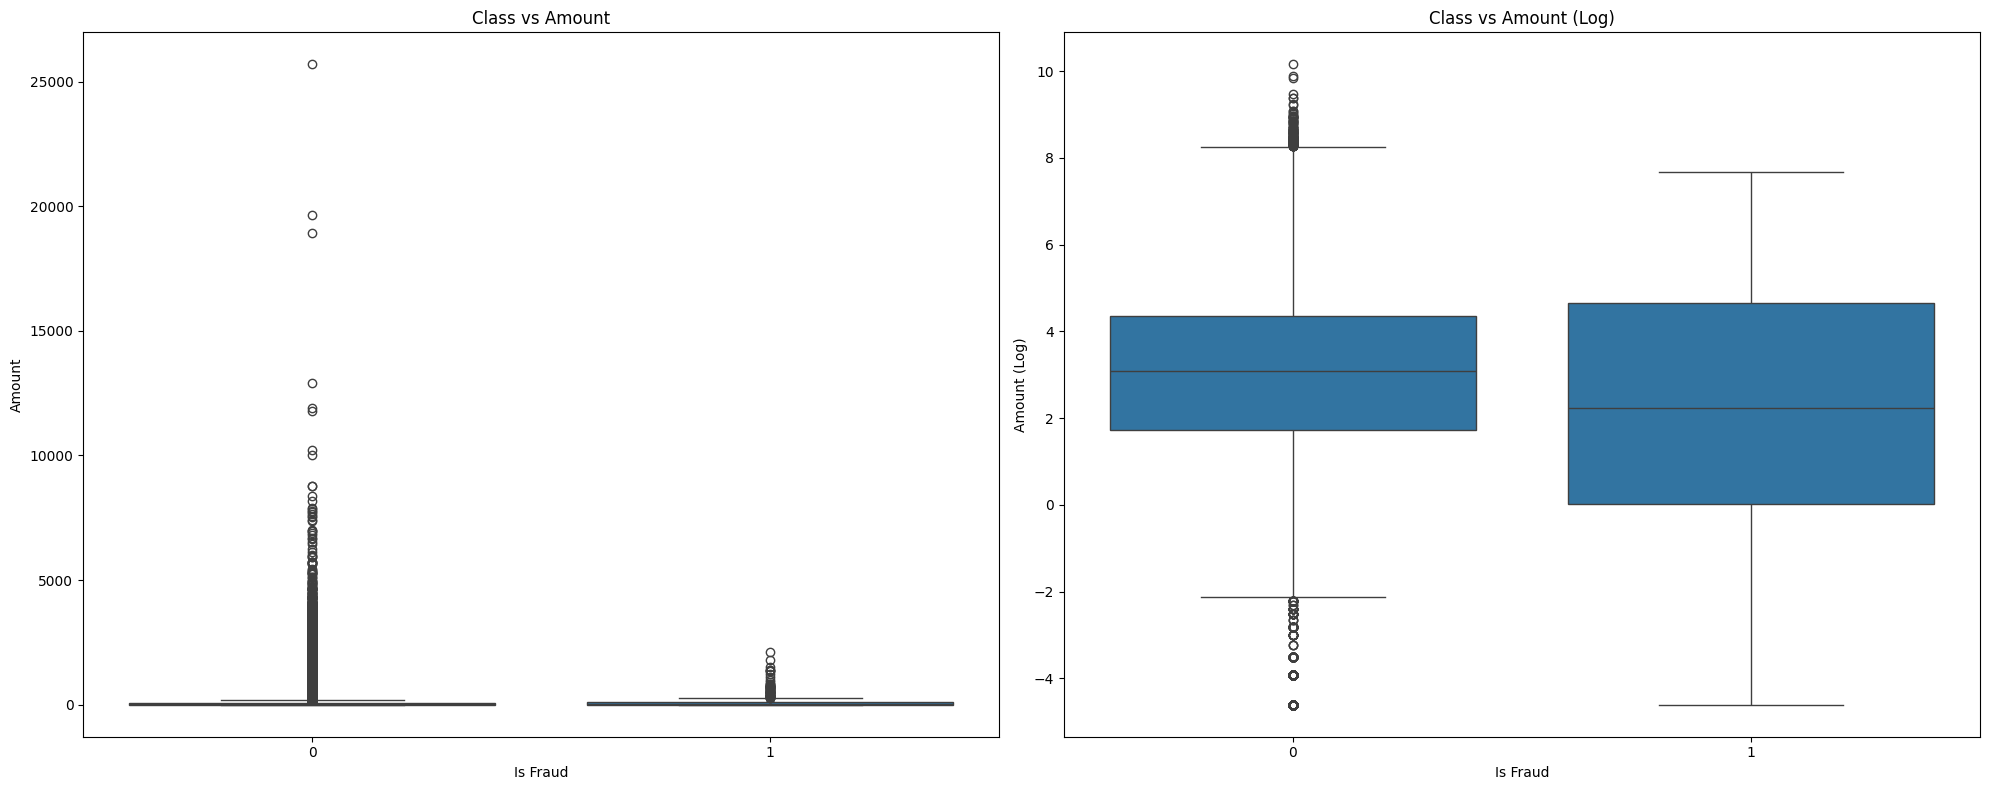

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
ax = sns.boxplot(x="Class", y="Amount", data=credit_card_data)
ax.set_title("Class vs Amount", fontsize=12)
ax.set_xlabel("Is Fraud")
ax.set_ylabel("Amount")

plt.subplot(1, 2, 2)
ax1 = sns.boxplot(x="Class", y="Amount_log", data=credit_card_data)
ax1.set_title("Class vs Amount (Log)", fontsize=12)
ax1.set_xlabel("Is Fraud")
ax1.set_ylabel("Amount (Log)")

plt.tight_layout()
plt.show()

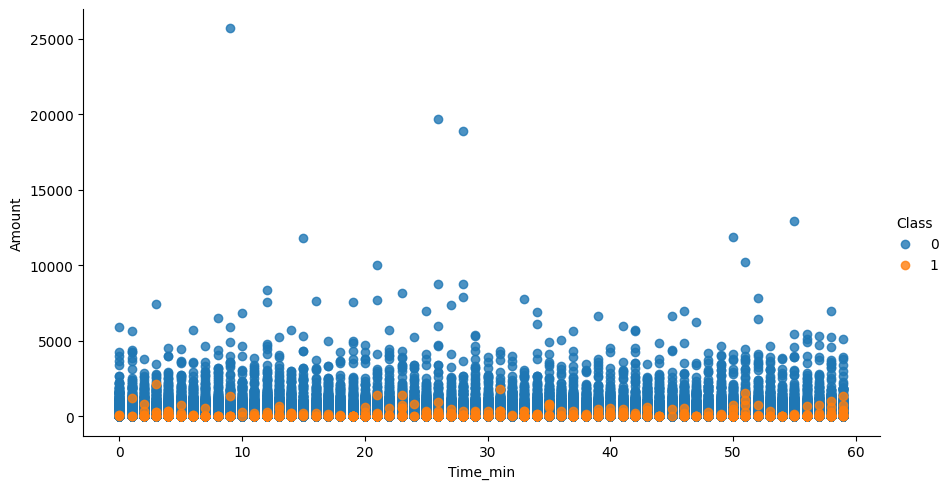

In [45]:
ax = sns.lmplot(y="Amount",x="Time_min",fit_reg = False,aspect=1.8, data = credit_card_data,hue = 'Class')
plt.show()

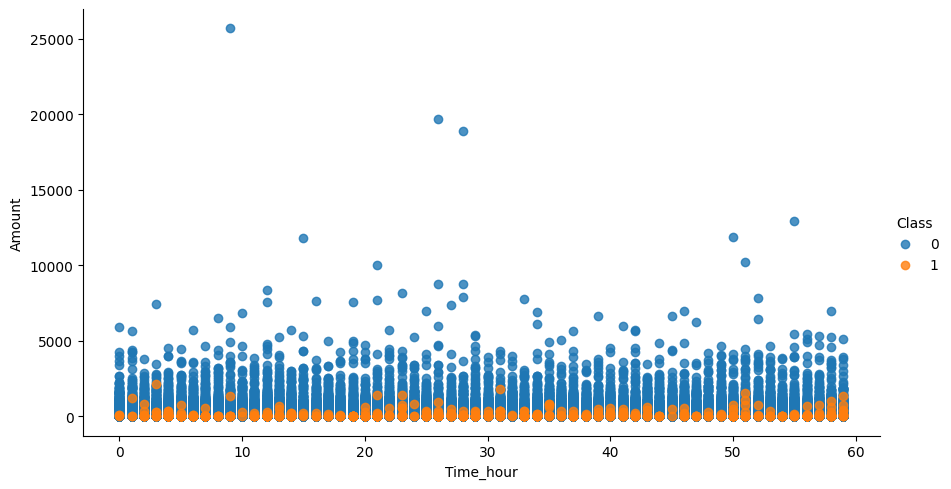

In [46]:
ax = sns.lmplot(y="Amount",x="Time_hour",fit_reg = False,aspect=1.8, data = credit_card_data,hue = 'Class')
plt.show()

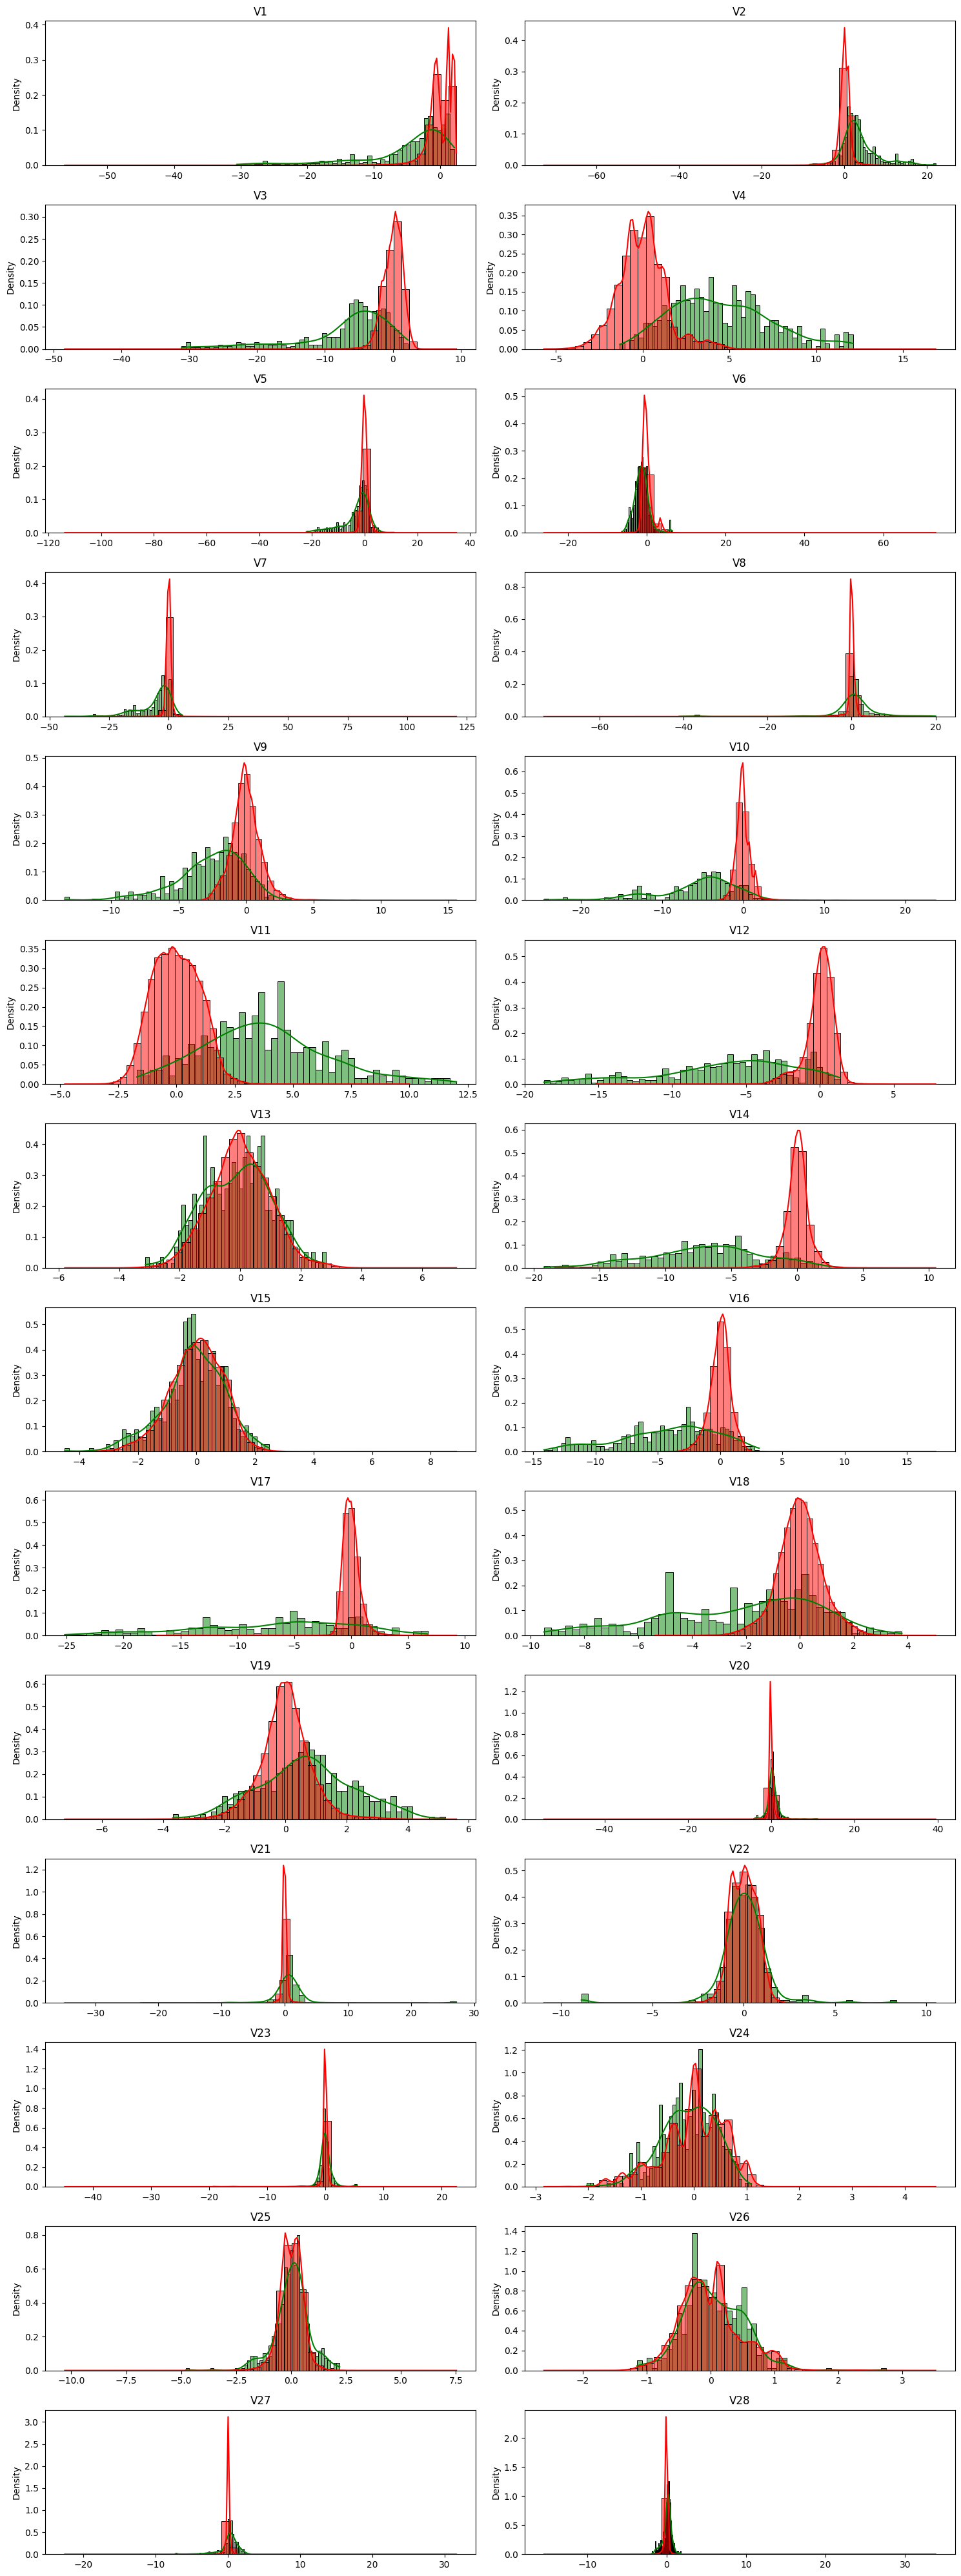

In [47]:
import matplotlib.gridspec as gridspec


columns = credit_card_data.iloc[:, 1:29].columns

frauds = credit_card_data["Class"] == 1
normal = credit_card_data["Class"] == 0

grid = gridspec.GridSpec(14, 2)

plt.figure(figsize=(15, 40))

for n, col in enumerate(columns):
    ax = plt.subplot(grid[n])

    sns.histplot(credit_card_data.loc[frauds, col],
                 bins=50, color='green',
                 stat='density', kde=True)

    sns.histplot(credit_card_data.loc[normal, col],
                 bins=50, color='red',
                 stat='density', kde=True)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [48]:
credit_card_data.Amount = np.log(credit_card_data.Amount+0.001)

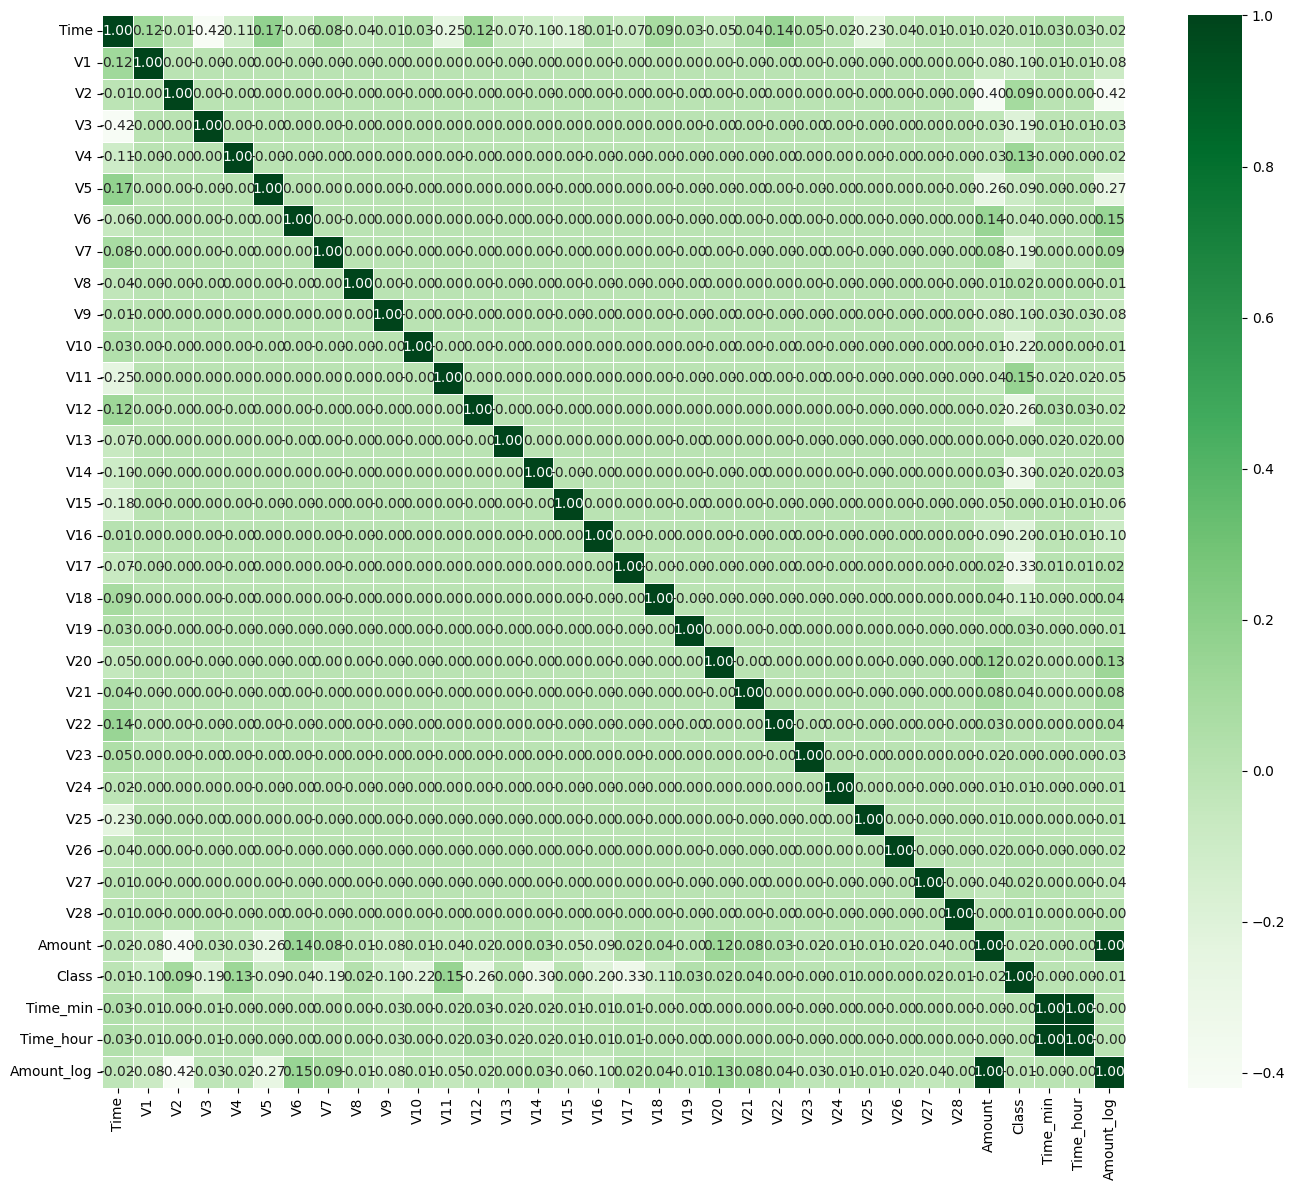

In [49]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    credit_card_data.corr(),
    cmap="Greens",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.tight_layout()
plt.show()

In [50]:
from imblearn.pipeline import make_pipeline as make_pipeline_imb
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import make_pipeline
from imblearn.metrics import classification_report_imbalanced

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from collections import Counter

from sklearn.metrics import (
    precision_score,
    confusion_matrix,
    recall_score,
    fbeta_score,
    precision_recall_curve,
    accuracy_score
)

In [51]:
X = credit_card_data.drop(["Class"],axis = 1).values

Y = credit_card_data["Class"].values

What SMOTE does:
Instead of just copying the existing rare fraud cases (which would just repeat the same points), SMOTE creates new, synthetic fraud examples by:

Picking a real fraud case
Looking at its nearest fraud neighbors
Creating a new "fake" fraud point somewhere in between them (not identical, but similar and realistic)

In [52]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

# Train Random Forest
smote_model = RandomForestClassifier(random_state=42)
smote_model.fit(X_train_smote, Y_train_smote)

# Prediction
smote_prediction = smote_model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(Y_test, smote_prediction))
print("Precision:", precision_score(Y_test, smote_prediction))
print("Recall   :", recall_score(Y_test, smote_prediction))
print("F1 Score :", f1_score(Y_test, smote_prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, smote_prediction))

print("\nClassification Report:")
print(classification_report(Y_test, smote_prediction))

Accuracy : 0.9994733330992591
Precision: 0.9203539823008849
Recall   : 0.7428571428571429
F1 Score : 0.8221343873517787

Confusion Matrix:
[[85294     9]
 [   36   104]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85303
           1       0.92      0.74      0.82       140

    accuracy                           1.00     85443
   macro avg       0.96      0.87      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score,GridSearchCV

In [54]:
param_grid = {
    "max_depth":[3,5,None],
    "n_estimators":[3,5,10],
    "max_features":[5,6,7,8]
    

}

model = RandomForestClassifier(max_features =3,
                               max_depth=2,
                               n_estimators =10,
                               random_state =3,
                              criterion = 'entropy',
                               n_jobs=1,verbose=1)


In [55]:
grid_search = GridSearchCV(model,param_grid,cv = 5,scoring = 'recall') 
grid_search.fit(X_train,Y_train)

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.3s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.3s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    3.5s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

,estimator,"RandomForestC...=3, verbose=1)"
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [5, 6, ...], 'n_estimators': [3, 5, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,5


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, classification_report

def print_results(title, y_true, y_pred, beta=1):
    print("\n" + title)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("F-beta   :", fbeta_score(y_true, y_pred, beta=beta))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [59]:
rf = RandomForestClassifier(max_depth=5,max_features=7,n_estimators=10)
rf.fit(X_train,Y_train)

print("Training score data:")
print(rf.score(X_train,Y_train))

Y_pred = rf.predict(X_test)

print(confusion_matrix(Y_test, Y_pred))

print_results("RF Classification", Y_test, Y_pred, beta=1)

Training score data:
0.9996037398928593
[[85296     7]
 [   38   102]]

RF Classification
Accuracy : 0.9994733330992591
Precision: 0.9357798165137615
Recall   : 0.7285714285714285
F1 Score : 0.8192771084337349
F-beta   : 0.8192771084337349

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85303
           1       0.94      0.73      0.82       140

    accuracy                           1.00     85443
   macro avg       0.97      0.86      0.91     85443
weighted avg       1.00      1.00      1.00     85443



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10640\3467547166.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90)


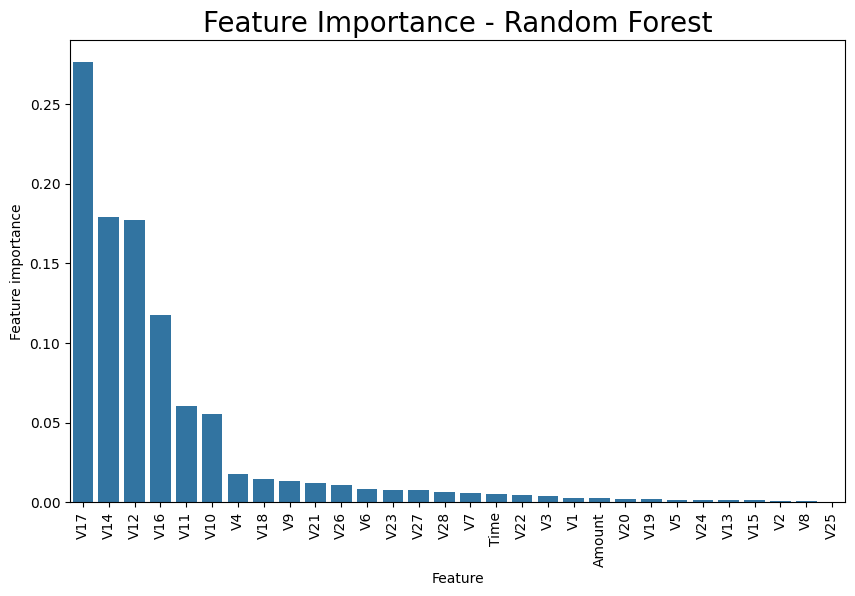

In [71]:
features = [
    'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
    'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14',
    'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26',
    'V27', 'V28', 'Amount',
    'Time_min', 'Time_hour', 'Amount_log'
]

plt.figure(figsize=(10,6))
features = features[:len(rf.feature_importances_)]

feat_import = pd.DataFrame({
    "Feature": features,
    "Feature importance": rf.feature_importances_
})

feat_import = feat_import.sort_values(by='Feature importance', ascending=False)

g = sns.barplot(x='Feature', y='Feature importance', data=feat_import)

g.set_xticklabels(g.get_xticklabels(), rotation=90)

g.set_title('Feature Importance - Random Forest', fontsize=20)

plt.show()

The Feature Importance graph indicates that only a few features have a significant impact on fraud detection, while the remaining features contribute relatively little. The Random Forest model assigns higher importance to the top-ranked features because they provide the most useful information for distinguishing fraudulent transactions from legitimate ones. This demonstrates that the model does not treat all features equally and focuses primarily on the most informative variables during classification.

##  MOEDELLING LOGISTIC REGRESSION WITH HYPER PARAMETERS

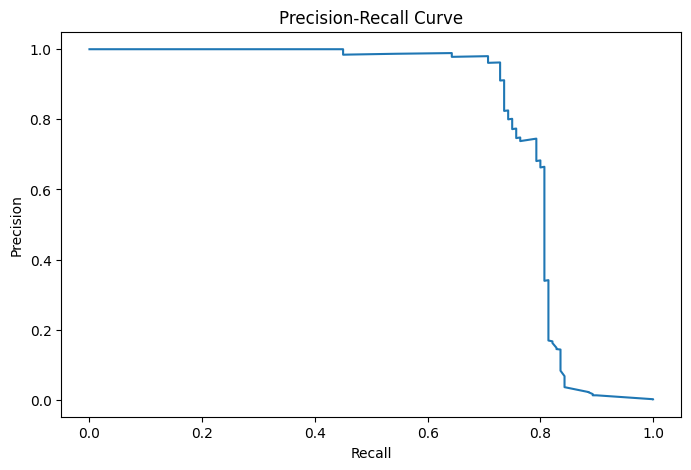

In [72]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Probability prediction
Y_pred_prob = rf.predict_proba(X_test)[:,1]

# Precision Recall values
precision, recall, thresholds = precision_recall_curve(
    Y_test,
    Y_pred_prob
)

# Plot
plt.figure(figsize=(8,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## SETTING THE BEST PERFORAMNCE AS PARAMETERW OF OUR MODEL

In [75]:
param_grid = {
    'C':[0.01,0.1,1,10],
    'penalty':['l1','l2']
}
logreg = LogisticRegression(solver = 'liblinear',random_state = 2)
grid_search_lr = GridSearchCV(logreg,
                              param_grid = param_grid,
                              scoring = 'recall',
                              cv = 5,
                             n_jobs = -1)

In [77]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logreg,
    X_train,
    Y_train,
    cv=10,
    scoring='recall'
)

print(cv_scores)
print("Mean Recall:", cv_scores.mean())

[0.68571429 0.62857143 0.63888889 0.55555556 0.65714286 0.65714286
 0.6        0.65714286 0.68571429 0.68571429]
Mean Recall: 0.6451587301587302


# PRECISION RECALL CURVE OF LR

[9.07077397e-05 7.75151660e-04 6.55579966e-04 5.72443245e-05
 2.36439255e-04]


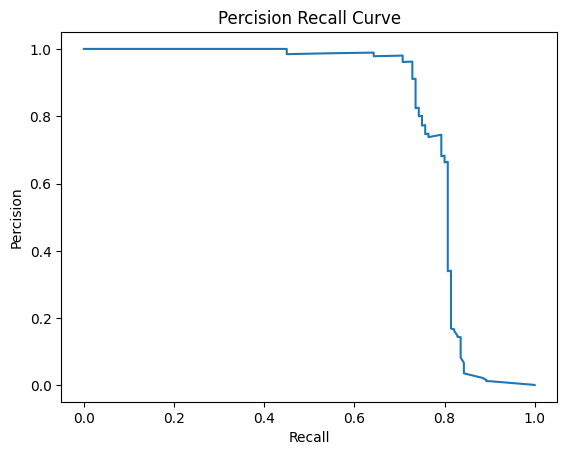

In [78]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    random_state=2
)

# Train
logreg.fit(X_train, Y_train)

# Probability prediction
Y_pred_prob = logreg.predict_proba(X_test)[:,1]

print(Y_pred_prob[:5])

plt.plot(recall,precision)

plt.xlabel('Recall')
plt.ylabel('Percision')
plt.title('Percision Recall Curve')
plt.show()